In [1]:
from cno.CNOModule import CNO
import matplotlib
import matplotlib.pyplot as plt
from neuralop.models import UNO
import torchinfo
from tqdm.auto import tqdm

from fun.models.custom_unet import CustomUNet
from fun.models.spectral_unet import SpectralResUNet
from fun.utils.diff_utils import DiffConv2d

matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 20})
#matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 45})
matplotlib.rc("legend", **{"fontsize": 16})
#matplotlib.rc("legend", **{"fontsize": 24})
matplotlib.rc("xtick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("xtick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("ytick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("ytick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("savefig", **{"dpi": 75, "pad_inches": 0.1})

/home/aa609734/.conda/envs/FNO-UNet/lib/python3.11/site-packages/torch/utils/cpp_extension.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]
No CUDA runtime is found, using CUDA_HOME='/home/aa609734/.conda/envs/FNO-UNet'


In [2]:
data = {"U-Net": [], "Diff. U-Net": [], "U-FNO": [], "FNO": [], "CNO": [], "U-NO": []}
TITLES = {
    "U-Net": "Classical U-Net",
    "Diff. U-Net": "Differential U-Net",
    "CNO": "CNO",
    "FNO": "Spectral U-Net",
    "U-FNO": "Spectral U-Net\n(resizing)",
    "U-NO": "U-NO",
}

for in_size in tqdm([16*i for i in range(1,65)]):
    #print(f"{in_size}x{in_size}:")
    for name in {"U-Net", "Diff. U-Net", "U-FNO", "FNO", "CNO", "U-NO"}:
        match name:
            case "U-Net": 
                model = CustomUNet(1, 1, use_checkpointing=False, nonresize_convs_per_block=1)
            case "Diff. U-Net": 
                model = CustomUNet(1, 1, use_checkpointing=False, nonresize_convs_per_block=1, conv_type=DiffConv2d, conv_kwargs={})
            case "U-FNO": 
                model = SpectralResUNet(1, 1, parametrization="spectral", u_shape=True, kbase1=256, kbase2=256)
            case "FNO":
                model = SpectralResUNet(1, 1, parametrization="spectral", u_shape=False, kbase1=256, kbase2=256)
            case "CNO": 
                model = CNO(in_dim=1, in_size=in_size, N_layers=4, N_res=3, N_res_neck=3, channel_multiplier=128)
            case "U-NO": 
                model = UNO(1, 1, 64, n_layers=9, uno_out_channels=[64, 64, 64, 64, 64, 64, 64, 64, 64], uno_n_modes=[[256, 256], [128, 128], [64, 64], [32, 32], [16, 16], [32, 32], [64, 64], [128, 128], [256, 256]], uno_scalings=[[1.0, 1.0], [0.5, 0.5], [0.5, 0.5], [0.5, 0.5], [0.5, 0.5], [2.0, 2.0], [2.0, 2.0], [2.0, 2.0], [2.0, 2.0]], skip="linear", fno_skip="linear", channel_mlp_skip="linear")
            case _:
                raise ValueError(f"Unknown model name: {name}")
        model_statistics = torchinfo.summary(model, input_size=(1, 1, in_size, in_size), verbose=0, device="meta")
        data[name].append((model_statistics.total_params, model_statistics.to_megabytes(model_statistics.total_param_bytes + model_statistics.total_output_bytes)))
    #    print(f"\t{name:>15}:   {model_statistics.total_params:15,}   {model_statistics.to_megabytes(model_statistics.total_param_bytes + model_statistics.total_output_bytes):8.2f} MB", flush=True)
    #print()

  0%|          | 0/64 [00:00<?, ?it/s]

/home/aa609734/.conda/envs/FNO-UNet/lib/python3.11/site-packages/neuralop/layers/spectral_convolution.py:509: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out_fft[slices_x] = torch.tensor(


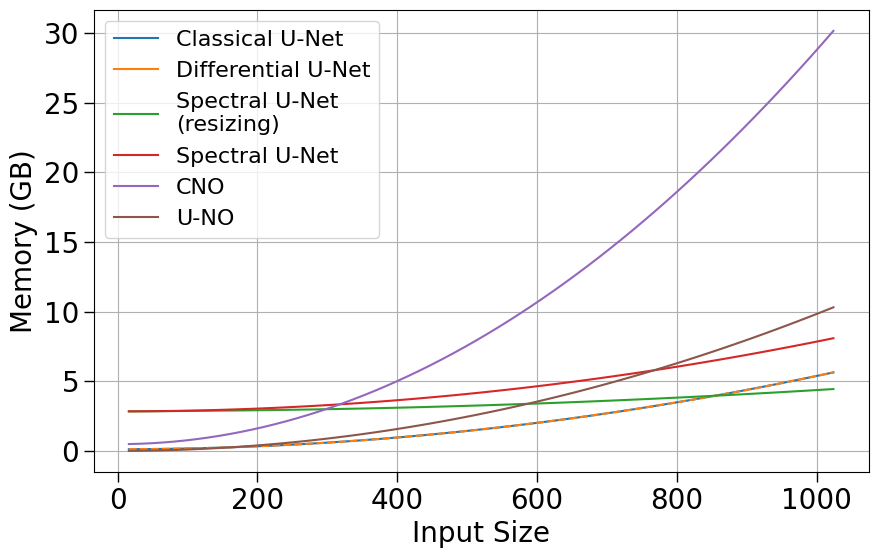

In [7]:
plt.figure(figsize=(10, 6))
for i, name in enumerate(data.keys()):
    #if name == "Diff. U-Net":
    #    continue
    sizes = [16*j for j in range(1,65)]
    #plt.plot(sizes, [d[0] for d in data[name]], f"C{i}--", label=name)
    if name == "Diff. U-Net":
        plt.plot(sizes, [d[1]/1024 for d in data[name]], f"C{i}--")
        plt.plot([], [], f"C{i}", label=TITLES[name])
    else:
        plt.plot(sizes, [d[1]/1024 for d in data[name]], f"C{i}", label=TITLES[name])
plt.xlabel("Input Size")
plt.ylabel("Memory (GB)")
plt.grid(True)
#plt.yscale("log")
plt.legend(loc="upper left")
plt.savefig("imgs/aa_mem_req.pdf", bbox_inches="tight")

In [ ]:
print("\\begin{table}")
print("\\centering")
print("\\begin{tabular}{" + "c" * len(data) + "}")
for name in data.keys():
    print(TITLES[name] + " & ", end="")
print("\\\\")
for name in data.keys():
    print(f"{data[name][0][0]:,}" + " & ", end="")
print("\\\\")
print("\\end{tabular}")
print("\\caption{}")
print("\\label{tab:params}")
print("\\end{table}")

\begin{table}
\centering
\begin{tabular}{cccccc}
Classical U-Net & Differential U-Net & Spectral U-Net
(resizing) & Spectral U-Net & CNO & U-NO & \
31,764,801 & 31,764,801 & 363,152,065 & 363,152,065 & 124,232,321 & 541,457,377 & \
\end{tabular}
\caption{}
\label{tab:params}
\end{table}
